# Case Study 2 — Report 6 (per-window)

**Transformer and Graph Neural Network architectures**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Add two new architectures from the brief — Transformer encoder and Graph Neural Network (GNN) — to the project's architectural comparison. Evaluated with the same DA variants (plain, DANN, MMD) as R4-R5 for direct comparison. Both protocols (per-window, per-trial).

**Architectures added:**
1. **Transformer encoder** — self-attention over 32 channel positions, treating DE features as a sequence. Multi-head attention learns cross-channel emotional patterns.
2. **GNN (Graph Convolutional Network)** — 32 channels as graph nodes, adjacency matrix from channel-pair correlation. Message passing captures spatial brain-region interactions.

**Grid.** 2 architectures × 3 tasks × 3 variants × 32 folds × 2 protocols = 1,152 fold-trainings.

**Speed optimizations.** DE data preloaded to GPU, cudnn.benchmark, batch tuned per protocol.

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [ ]:
import torch, numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.autograd import Function

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, confusion_matrix)
from scipy.stats import ttest_1samp

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration
Protocol selected via `PROTOCOL` — run this notebook once per protocol.

In [ ]:
PROTOCOL = 'per_window'

CONFIG = {
    'per_window_de':     'processed/X_deap_DE_zscored.npy',
    'subject_id_path':   'processed/deap_subject_ids.npy',
    'valence_path':      'processed/y_deap_valence.npy',
    'arousal_path':      'processed/y_deap_arousal.npy',
    'labels_3c_path':    'processed/y_deap_3class.npy',

    'results_dir':    f'results/report6_{PROTOCOL}',
    'checkpoint_dir': f'checkpoints/report6_{PROTOCOL}',

    'architectures': ['transformer', 'gnn'],
    'tasks':    ['valence', 'arousal', '3class'],
    'variants': ['plain', 'dann', 'mmd'],

    # Per-window vs per-trial hyperparameters
    'batch_size':    512 if PROTOCOL == 'per_window' else 128,
    'epochs':        20  if PROTOCOL == 'per_window' else 40,
    'lr':            1e-3,
    'weight_decay':  1e-4,
    'early_stop_patience': 5 if PROTOCOL == 'per_window' else 8,

    'dann_lambda_max':  1.0,
    'dann_ramp_epochs': 10 if PROTOCOL == 'per_window' else 15,
    'mmd_lambda':       0.5 if PROTOCOL == 'per_window' else 0.1,

    'folds_to_run': None,

    # Architecture hyperparameters
    'transformer_dim':   64,
    'transformer_heads': 4,
    'transformer_layers': 2,
    'transformer_dropout': 0.2,

    'gnn_hidden': 64,
    'gnn_layers': 2,
    'gnn_dropout': 0.2,
    'gnn_adj_top_k': 8,   # keep top-K correlations per channel in adjacency
}

RESULTS_DIR    = Path(PROJECT_ROOT) / CONFIG['results_dir']
CHECKPOINT_DIR = Path(PROJECT_ROOT) / CONFIG['checkpoint_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Protocol: {PROTOCOL}')
print(f'Results:  {RESULTS_DIR}')

Protocol: per_window
Results:  /content/drive/MyDrive/case_study_2/results/report6_per_window


## 3. Data loading — protocol-dependent

In [ ]:
root = Path(PROJECT_ROOT)
X_win = np.load(root / CONFIG['per_window_de']).astype(np.float32)
subj_win = np.load(root / CONFIG['subject_id_path'])
labels_win = {
    'val_bin': np.load(root / CONFIG['valence_path']).astype(np.int64),
    'aro_bin': np.load(root / CONFIG['arousal_path']).astype(np.int64),
    'val_3c':  np.load(root / CONFIG['labels_3c_path']).astype(np.int64),
}

if PROTOCOL == 'per_trial':
    # Aggregate per-window DE to per-trial (Method A from R4B)
    N = X_win.shape[0]
    n_sub, n_trial = 32, 40
    n_win = N // (n_sub * n_trial)
    X_reshaped = X_win.reshape(n_sub, n_trial, n_win, -1)
    X_np = X_reshaped.mean(axis=2).reshape(n_sub * n_trial, -1)
    LABELS_np = {}
    for k, v in labels_win.items():
        v_reshaped = v.reshape(n_sub, n_trial, n_win)
        LABELS_np[k] = v_reshaped[:, :, 0].reshape(-1).astype(np.int64)
    SUBJ_np = np.repeat(np.arange(1, n_sub + 1), n_trial).astype(np.int64)
else:
    X_np = X_win
    SUBJ_np = subj_win
    LABELS_np = labels_win

X_gpu    = torch.from_numpy(X_np).to(DEVICE)
SUBJ_gpu = torch.from_numpy(SUBJ_np.astype(np.int64)).to(DEVICE)
LABELS_gpu = {k: torch.from_numpy(v).to(DEVICE) for k, v in LABELS_np.items()}

UNIQUE_SUBJECTS = np.unique(SUBJ_np)
N_SUBJECTS = len(UNIQUE_SUBJECTS)
print(f'X ({PROTOCOL}): {X_np.shape}, ~{X_np.nbytes/1e6:.1f} MB on GPU')
print(f'Subjects: {UNIQUE_SUBJECTS.tolist()}')

X (per_window): (152320, 160), ~97.5 MB on GPU
Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


In [ ]:
def get_task_labels_gpu(task):
    return {'valence': LABELS_gpu['val_bin'],
            'arousal': LABELS_gpu['aro_bin'],
            '3class':  LABELS_gpu['val_3c']}[task]

def get_n_classes(task):
    return 3 if task == '3class' else 2

## 4. Shared components — GRL, MMD, evaluation

In [ ]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

EMBED_DIM = 128

## 5. Transformer architecture

- Reshape DE `(N, 160)` → `(N, 32 channels, 5 bands)`
- Linear projection: 5 → d_model
- Learnable positional embedding for 32 channel positions
- Transformer encoder (multi-head self-attention over channels)
- Mean pooling over channels → 128-d embedding

In [ ]:
class TransformerExtractor(nn.Module):
    def __init__(self, n_channels=32, n_bands=5, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2, embed=EMBED_DIM):
        super().__init__()
        self.n_channels = n_channels
        self.input_proj = nn.Linear(n_bands, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, n_channels, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Sequential(nn.Linear(d_model, embed), nn.ReLU(), nn.Dropout(dropout))

    def forward(self, x):
        b = x.size(0)
        x = x.view(b, self.n_channels, -1)   # (B, 32, 5)
        x = self.input_proj(x)               # (B, 32, d_model)
        x = x + self.pos_embed               # positional encoding
        x = self.encoder(x)                  # (B, 32, d_model)
        x = x.mean(dim=1)                    # global average pool over channels
        return self.fc(x)

## 6. GNN architecture

- Reshape DE `(N, 160)` → `(N, 32 channels, 5 bands)`
- Build fixed adjacency matrix from channel-pair correlation (computed once at fold start on training data)
- Keep top-K neighbors per channel (sparse graph)
- 2 GCN layers with ReLU + dropout
- Mean pooling over nodes → 128-d embedding

In [ ]:
def build_channel_adjacency(X_train_np, n_channels=32, n_bands=5, top_k=8):
    """Compute channel-pair correlation across all training samples, keep top-K per channel."""
    X_reshaped = X_train_np.reshape(-1, n_channels, n_bands)
    channel_signals = X_reshaped.transpose(1, 0, 2).reshape(n_channels, -1)  # (32, N*5)
    corr = np.corrcoef(channel_signals)                                       # (32, 32)
    corr = np.abs(corr)
    np.fill_diagonal(corr, 0)

    # Keep top-K neighbors per channel
    adj = np.zeros_like(corr)
    for i in range(n_channels):
        top = np.argsort(corr[i])[-top_k:]
        adj[i, top] = corr[i, top]
    # Symmetrize
    adj = np.maximum(adj, adj.T)
    # Add self-loops
    adj = adj + np.eye(n_channels, dtype=np.float32)
    # Normalize (D^-0.5 A D^-0.5)
    deg = adj.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(deg + 1e-10)
    adj_norm = adj * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]
    return torch.tensor(adj_norm, dtype=torch.float32).to(DEVICE)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
    def forward(self, x, adj):
        # x: (B, N, F), adj: (N, N)
        return self.lin(adj @ x)

class GNNExtractor(nn.Module):
    def __init__(self, n_bands=5, hidden=64, num_layers=2, dropout=0.2, embed=EMBED_DIM):
        super().__init__()
        self.layers = nn.ModuleList([GCNLayer(n_bands if i == 0 else hidden, hidden)
                                     for i in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(nn.Linear(hidden, embed), nn.ReLU(), nn.Dropout(dropout))
        self.adj = None   # set per fold before training

    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5)
        for layer in self.layers:
            x = F.relu(layer(x, self.adj))
            x = self.dropout(x)
        x = x.mean(dim=1)                    # global average pool over nodes
        return self.fc(x)

## 7. EmotionModel wrapper (both architectures)

In [ ]:
def make_extractor(arch):
    if arch == 'transformer':
        return TransformerExtractor(
            n_channels=32, n_bands=5,
            d_model=CONFIG['transformer_dim'], nhead=CONFIG['transformer_heads'],
            num_layers=CONFIG['transformer_layers'], dropout=CONFIG['transformer_dropout'])
    elif arch == 'gnn':
        return GNNExtractor(
            n_bands=5, hidden=CONFIG['gnn_hidden'],
            num_layers=CONFIG['gnn_layers'], dropout=CONFIG['gnn_dropout'])
    else:
        raise ValueError(arch)

class EmotionModel(nn.Module):
    def __init__(self, arch, n_classes, use_dann=False, n_domains=None):
        super().__init__()
        self.extractor  = make_extractor(arch)
        self.label_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
        self.use_dann = use_dann
        if use_dann:
            self.domain_head = nn.Sequential(
                nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, n_domains))

    def forward(self, x, alpha=0.0, return_features=False):
        feat = self.extractor(x)
        logits = self.label_head(feat)
        dom_logits = None
        if self.use_dann:
            dom_logits = self.domain_head(grad_reverse(feat, alpha))
        if return_features:
            return logits, dom_logits, feat
        return logits, dom_logits

## 8. Training utilities

In [ ]:
@torch.no_grad()
def evaluate(model, X_te, y_te, batch_size=512):
    model.eval()
    preds = []
    for i in range(0, X_te.size(0), batch_size):
        logits, _ = model(X_te[i:i+batch_size], alpha=0.0)
        preds.append(logits.argmax(dim=1))
    y_pred = torch.cat(preds).cpu().numpy()
    y_true = y_te.cpu().numpy()
    return y_true, y_pred, balanced_accuracy_score(y_true, y_pred)

def train_fold(model, X_tr, y_tr, s_tr, X_te, y_te,
               variant, epochs, lr, wd, patience,
               dann_lambda_max, dann_ramp_epochs, mmd_lambda,
               batch_size, n_classes):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    # Class-balanced loss
    counts = np.bincount(y_tr.cpu().numpy(), minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_bal, best_state, patience_ctr = -1.0, None, 0
    n = X_tr.size(0)

    for ep in range(epochs):
        alpha = dann_lambda_max * min(1.0, ep / max(dann_ramp_epochs, 1)) if variant == 'dann' else 0.0
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb, yb, sb = X_tr[idx], y_tr[idx], s_tr[idx]
            opt.zero_grad()
            if variant == 'mmd':
                logits, _, feat = model(xb, alpha=0.0, return_features=True)
                loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            else:
                logits, dom_logits = model(xb, alpha=alpha)
                loss = loss_fn(logits, yb)
                if variant == 'dann' and dom_logits is not None:
                    loss = loss + F.cross_entropy(dom_logits, sb)
            loss.backward()
            opt.step()
        sched.step()

        _, _, bal = evaluate(model, X_te, y_te, batch_size=batch_size*2)
        if bal > best_bal + 1e-4:
            best_bal, patience_ctr = bal, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_bal

## 9. LOSO runner

In [ ]:
def run_loso(arch, task, variant):
    y_all = get_task_labels_gpu(task)
    n_classes = get_n_classes(task)

    run_id = f'{arch}_{task}_{variant}'
    ckpt_path = CHECKPOINT_DIR / f'{run_id}_folds.pkl'

    fold_results = {}
    if ckpt_path.exists():
        with open(ckpt_path, 'rb') as f:
            fold_results = pickle.load(f)
        print(f'[{run_id}] resuming: {len(fold_results)} folds done')

    folds = CONFIG['folds_to_run'] or sorted(int(s) for s in UNIQUE_SUBJECTS)

    for held_out in tqdm(folds, desc=run_id):
        if held_out in fold_results: continue

        tr_idx = torch.where(SUBJ_gpu != held_out)[0]
        te_idx = torch.where(SUBJ_gpu == held_out)[0]
        X_tr, y_tr, s_tr = X_gpu[tr_idx], y_all[tr_idx], SUBJ_gpu[tr_idx]
        X_te, y_te = X_gpu[te_idx], y_all[te_idx]

        unique_s = torch.unique(s_tr)
        remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
        remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
        s_tr_remap = remap[s_tr]
        n_domains = int(unique_s.size(0))

        use_dann = (variant == 'dann')
        model = EmotionModel(arch, n_classes, use_dann=use_dann, n_domains=n_domains)

        # GNN needs adjacency computed from THIS fold's training data
        if arch == 'gnn':
            adj = build_channel_adjacency(
                X_tr.cpu().numpy(), n_channels=32, n_bands=5,
                top_k=CONFIG['gnn_adj_top_k'])
            model.extractor.adj = adj

        t0 = time.time()
        model, best_bal = train_fold(
            model, X_tr, y_tr, s_tr_remap, X_te, y_te,
            variant, CONFIG['epochs'], CONFIG['lr'], CONFIG['weight_decay'],
            CONFIG['early_stop_patience'],
            CONFIG['dann_lambda_max'], CONFIG['dann_ramp_epochs'], CONFIG['mmd_lambda'],
            CONFIG['batch_size'], n_classes)
        elapsed = time.time() - t0

        y_true, y_pred, _ = evaluate(model, X_te, y_te, batch_size=CONFIG['batch_size']*2)
        fold_results[held_out] = {
            'sid': int(held_out), 'y_true': y_true, 'y_pred': y_pred,
            'elapsed_s': elapsed,
            'acc': accuracy_score(y_true, y_pred),
            'bal_acc': balanced_accuracy_score(y_true, y_pred),
        }

        with open(ckpt_path, 'wb') as f:
            pickle.dump(fold_results, f)

        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return fold_results

## 10. Main grid — 2 architectures × 3 tasks × 3 variants × 32 folds

In [ ]:
ALL_RESULTS = {}
for arch in CONFIG['architectures']:
    for task in CONFIG['tasks']:
        for variant in CONFIG['variants']:
            key = (arch, task, variant)
            print(f'\n{"="*60}\n{arch} | {task} | {variant}\n{"="*60}')
            ALL_RESULTS[key] = run_loso(arch, task, variant)


transformer | valence | plain


transformer_valence_plain:   0%|          | 0/32 [00:00<?, ?it/s]


transformer | valence | dann


transformer_valence_dann:   0%|          | 0/32 [00:00<?, ?it/s]


transformer | valence | mmd


...

gnn_3class_dann:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics


gnn | 3class | mmd


gnn_3class_mmd:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

## 11. Aggregate + save

In [ ]:
def aggregate_fold(fold_results, task):
    n_classes = get_n_classes(task)
    per_fold, all_true, all_pred = [], [], []
    for sid, r in sorted(fold_results.items()):
        y_true, y_pred = r['y_true'], r['y_pred']
        all_true.append(y_true); all_pred.append(y_pred)
        per_fold.append({
            'sid': r['sid'],
            'acc': 100 * accuracy_score(y_true, y_pred),
            'bal': 100 * balanced_accuracy_score(y_true, y_pred),
            'f1_w': 100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
        })
    df = pd.DataFrame(per_fold)
    if all_true:
        cm = confusion_matrix(np.concatenate(all_true), np.concatenate(all_pred),
                              labels=list(range(n_classes)))
    else:
        cm = np.zeros((n_classes, n_classes))
    chance = 100.0 / n_classes
    t_stat, p_val = ttest_1samp(df['bal'], chance, alternative='greater')
    summary = {
        'bal_mean': df['bal'].mean(), 'bal_std': df['bal'].std(),
        'acc_mean': df['acc'].mean(), 'p_value': p_val,
        'above_chance': p_val < 0.05,
    }
    return df, cm, summary

rows, per_fold_all, cms_all = [], {}, {}
for (arch, task, variant), fr in ALL_RESULTS.items():
    df, cm, summ = aggregate_fold(fr, task)
    per_fold_all[(arch, task, variant)] = df
    cms_all[(arch, task, variant)] = cm
    rows.append({'protocol': PROTOCOL, 'arch': arch, 'task': task, 'variant': variant, **summ})

SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_all_runs.csv', index=False)
print(SUMMARY.to_string(index=False))

for key, df in per_fold_all.items():
    df.to_csv(RESULTS_DIR / f'per_fold_{"_".join(key)}.csv', index=False)
for key, cm in cms_all.items():
    np.save(RESULTS_DIR / f'cm_{"_".join(key)}.npy', cm)
print(f'\nSaved to: {RESULTS_DIR}')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  protocol        arch    task variant  bal_mean  bal_std  acc_mean      p_value  above_chance
per_window transformer valence   plain 56.622283 6.535867 56.336660 1.319101e-06          True
per_window transformer valence    dann 54.815593 5.168177 57.127757 4.937766e-06          True
per_window transformer valence     mmd 50.121838 0.405174 53.419118 4.947250e-02          True
per_window transformer arousal   plain 53.942000 4.306618 52.775079 6.447728e-06          True
per_window transformer arousal    dann 54.115022 3.970033 54.320509 9.053497e-07          True
per_window transformer arousal     mmd 50.003735 0.018663 46.644564 1.331135e-01         False
per_window transformer  3class   plain 38.859701 3.998825 39.828650 4.010294e-09          True
per_window transformer  3class    dann 38.613288 5.756776 40.098477 6.258389e-06          True
per_window transformer  3class     mmd 33.983561 3.004246 33.908220 1.150222e-01         False
per_window         gnn valence   plain 54.359691 6

## 12. Plots — figures for the R6 docx

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

### 12.1 Architecture comparison — Transformer vs GNN across tasks and variants

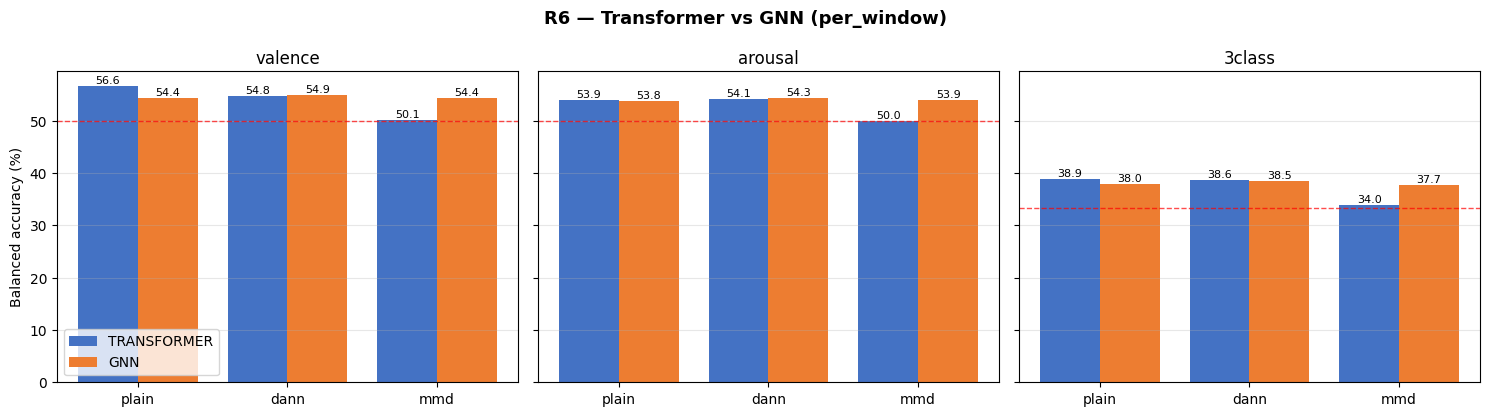

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
tasks = ['valence', 'arousal', '3class']
variants = ['plain', 'dann', 'mmd']
colors = {'transformer': '#4472C4', 'gnn': '#ED7D31'}

for ax, task in zip(axes, tasks):
    x = np.arange(len(variants))
    w = 0.4
    for i, arch in enumerate(['transformer', 'gnn']):
        vals = []
        for v in variants:
            key = (arch, task, v)
            if key in per_fold_all:
                vals.append(per_fold_all[key]['bal'].mean())
            else:
                vals.append(0)
        offset = (i - 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=arch.upper(), color=colors[arch])
        for b, v_ in zip(bars, vals):
            if v_ > 0:
                ax.text(b.get_x() + b.get_width()/2, v_ + 0.5,
                        f'{v_:.1f}', ha='center', fontsize=8)
    chance = 50.0 if task != '3class' else 33.3
    ax.axhline(chance, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(variants)
    ax.set_title(f'{task}')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Balanced accuracy (%)')
axes[0].legend()
plt.suptitle(f'R6 — Transformer vs GNN ({PROTOCOL})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'r6_arch_comparison_{PROTOCOL}.png', dpi=140, bbox_inches='tight')
plt.show()

### 12.2 Best config — per-subject balanced accuracy

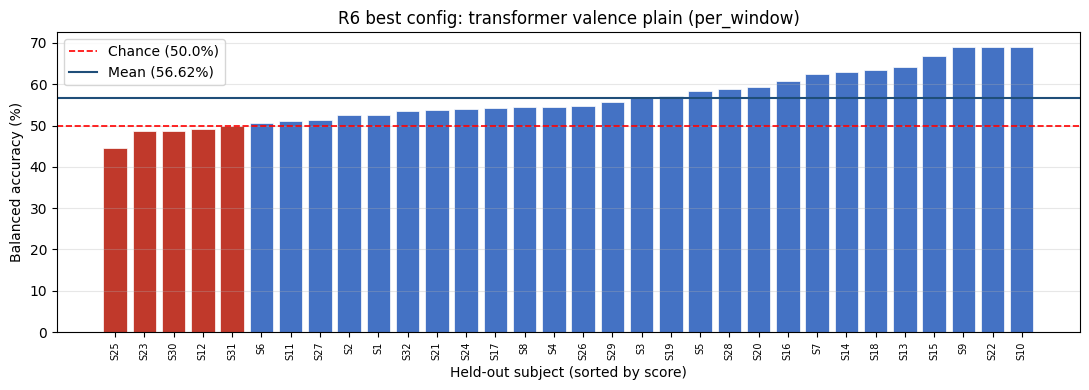

In [ ]:
# Find best config
best_key, best_bal = None, -1
for key, df in per_fold_all.items():
    if df['bal'].mean() > best_bal:
        best_bal = df['bal'].mean()
        best_key = key

df = per_fold_all[best_key].sort_values('bal').reset_index(drop=True)
task = best_key[1]
chance = 100.0 / get_n_classes(task)
mean_bal = df['bal'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
colors_bar = ['#c0392b' if v < chance else '#4472C4' for v in df['bal']]
ax.bar(range(len(df)), df['bal'], color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axhline(chance, color='red', linestyle='--', linewidth=1.2, label=f'Chance ({chance:.1f}%)')
ax.axhline(mean_bal, color='#1F4E79', linewidth=1.5, label=f'Mean ({mean_bal:.2f}%)')
ax.set_xlabel('Held-out subject (sorted by score)')
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title(f'R6 best config: {best_key[0]} {best_key[1]} {best_key[2]} ({PROTOCOL})')
ax.set_xticks(range(len(df)))
ax.set_xticklabels([f'S{int(s)}' for s in df['sid']], rotation=90, fontsize=7)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'r6_persub_best_{PROTOCOL}.png', dpi=140, bbox_inches='tight')
plt.show()

### 12.3 Confusion matrix — best config

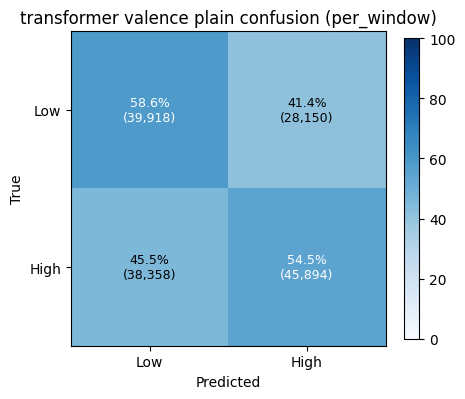

In [ ]:
cm = cms_all[best_key].astype(float)
if cm.sum() > 0:
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-10) * 100
    n = cm.shape[0]
    names = ['Low', 'High'] if task in ('valence', 'arousal') else ['Neg', 'Neu', 'Pos']
    fig, ax = plt.subplots(figsize=(4.8, 4.1))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n):
        for j in range(n):
            c = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i, j]:.1f}%\n({int(cm[i, j]):,})',
                    ha='center', va='center', color=c, fontsize=9)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{best_key[0]} {best_key[1]} {best_key[2]} confusion ({PROTOCOL})')
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'r6_confusion_best_{PROTOCOL}.png', dpi=140, bbox_inches='tight')
    plt.show()

### 12.4 R6 vs previous reports — where does R6 sit

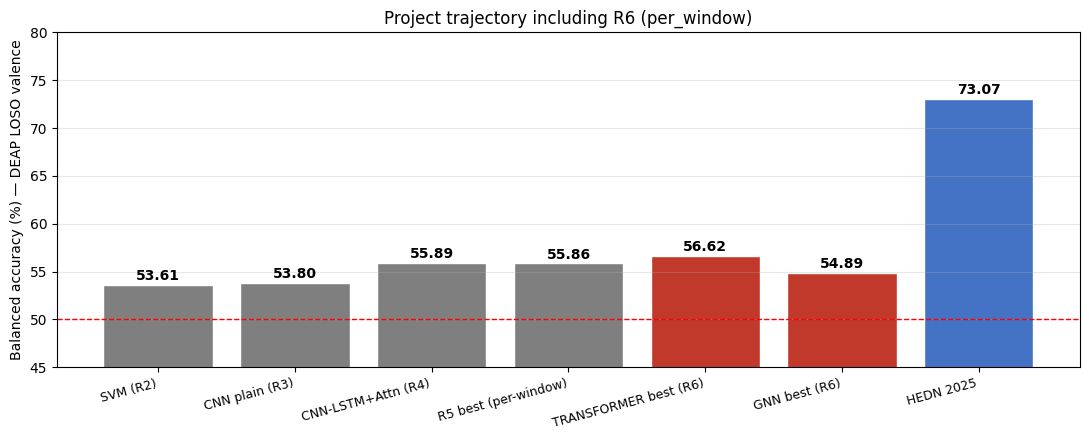

In [ ]:
# Best per-report valence figures (from your project)
if PROTOCOL == 'per_window':
    prev = {'SVM (R2)': 53.61, 'CNN plain (R3)': 53.80, 'CNN-LSTM+Attn (R4)': 55.89,
            'R5 best (per-window)': 55.86}
    hedn = 73.07
    ylim = (45, 80)
else:
    prev = {'CNN-LSTM+Attn plain (R4B)': 64.19, 'CNN-LSTM+Attn MMD (R4B)': 65.31,
            'R5 best (per-trial)': 64.81}
    hedn = 73.07
    ylim = (55, 80)

# Add R6 valence best per architecture
r6_bests = {}
for arch in ['transformer', 'gnn']:
    vals = [per_fold_all[(arch, 'valence', v)]['bal'].mean()
            for v in ['plain', 'dann', 'mmd']
            if (arch, 'valence', v) in per_fold_all]
    if vals:
        r6_bests[f'{arch.upper()} best (R6)'] = max(vals)

all_labels = list(prev.keys()) + list(r6_bests.keys()) + ['HEDN 2025']
all_vals = list(prev.values()) + list(r6_bests.values()) + [hedn]
colors_bar = ['#7f7f7f'] * len(prev) + ['#c0392b'] * len(r6_bests) + ['#4472C4']

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(all_labels, all_vals, color=colors_bar, edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1)
for b, v_ in zip(bars, all_vals):
    ax.text(b.get_x() + b.get_width()/2, v_ + 0.5, f'{v_:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Balanced accuracy (%) — DEAP LOSO valence')
ax.set_title(f'Project trajectory including R6 ({PROTOCOL})')
ax.set_ylim(*ylim)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'r6_trajectory_{PROTOCOL}.png', dpi=140, bbox_inches='tight')
plt.show()